In [1]:
import os
import cv2
import numpy as np
from joblib import Parallel, delayed
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split

In [2]:
base_path="Dataset_videos"
real_videos=os.listdir(os.path.join(base_path,"Real"))
fake_videos=os.listdir(os.path.join(base_path,"Fake"))
print("Real:",len(real_videos))
print("Fake:",len(fake_videos))

Real: 1083
Fake: 1080


In [3]:
def extract_frames(video_path,img_size=224,max_frames=20):
    cap=cv2.VideoCapture(video_path)
    frames=[]
    total_frames=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    total_frames=min(total_frames,200)
    step=max(1,total_frames//max_frames)
    for i in range(0,total_frames,step):
        cap.set(cv2.CAP_PROP_POS_FRAMES,i)
        ret,frame=cap.read()
        if not ret:
            break
        frame=cv2.resize(frame,(img_size,img_size))
        frame=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
        frames.append(frame)
        if len(frames)>=max_frames:
            break
    cap.release()
    return frames

In [4]:
def process_video(video_path, label):
    frames=extract_frames(video_path)
    return [(f,label) for f in frames]

In [5]:
X=[]
y=[]
tasks=[]

for video in real_videos[:200]:
    tasks.append((os.path.join(base_path,"Real",video), 0))

for video in fake_videos[:200]:
    tasks.append((os.path.join(base_path,"Fake",video), 1))

print("Processing videos...")

results=Parallel(n_jobs=-1)(
    delayed(process_video)(path,label) for path, label in tasks
)

for res in results: 
    for frame,label in res:
        X.append(frame)
        y.append(label)

X=np.array(X)
y=np.array(y)

print("Total frames:",len(X))

Processing videos...
Total frames: 7978


In [6]:
X=preprocess_input(X) 

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
base_model=EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable=False

for layer in base_model.layers[-20:]:
    layer.trainable=True

x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(128,activation='relu')(x)
x=Dropout(0.5)(x)
output=Dense(1,activation='sigmoid')(x)

model=Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history=model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,   
    batch_size=32
)

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.6905 - loss: 0.5607 - val_accuracy: 0.7249 - val_loss: 0.5187
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 193s 964ms/step - accuracy: 0.7355 - loss: 0.4865 - val_accuracy: 0.7375 - val_loss: 0.4863
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.7462 - loss: 0.4681 - val_accuracy: 0.7412 - val_loss: 0.4783
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 186s 929ms/step - accuracy: 0.7623 - loss: 0.4516 - val_accuracy: 0.7469 - val_loss: 0.4724
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 199s 998ms/step - accuracy: 0.7640 - loss: 0.4400 - val_accuracy: 0.7682 - val_loss: 0.4517
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 182s 910ms/step - accuracy: 0.7715 - loss: 0.4350 - val_accuracy: 0.7807 - val_loss: 0.4362
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 186s 928ms/step - accuracy: 0.7903 - loss: 0.4106 - val_accuracy: 0.7701 - val_loss: 0.4263
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.7914 - loss: 0.

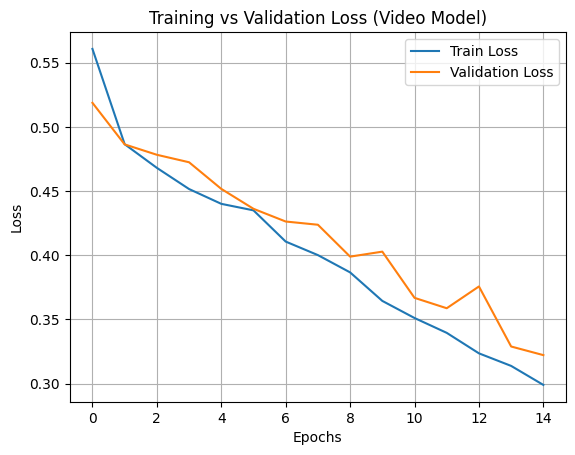

In [10]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Video Model)')
plt.legend()
plt.grid()
plt.show()    

50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 648ms/step


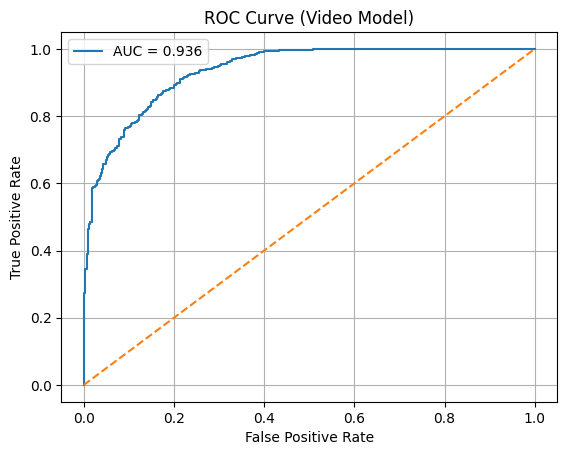

In [12]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Video Model)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
def predict_video(video_path,model):

    frames=extract_frames(video_path,max_frames=20)

    preds=[]

    for frame in frames:
        frame=preprocess_input(frame)  
        frame=np.expand_dims(frame,axis=0)

        prob=model.predict(frame,verbose=0)[0][0]
        preds.append(prob)

    if len(preds)==0:
        return "Real", 0.0

    avg_pred=sum(preds)/len(preds)
    label="Fake" if avg_pred>=0.6 else "Real"
    return label,avg_pred

In [ ]:
from tqdm import tqdm
correct=0
total=0
for label in ["Real", "Fake"]:
    folder=os.path.join(base_path,label)
    videos=os.listdir(folder)[:200]
    for video in tqdm(videos, desc=f"Processing{label}",disable=True):
        path=os.path.join(folder,video)
        pred, prob=predict_video(path,model)
        if pred.lower()==label.lower():
            correct+=1

        total+=1

        if total%100==0:
            print(f"Processed{total}videos...")

print("\n Final Video Accuracy:",(correct / total)*100)

Processed 100 videos...
Processed 200 videos...
Processed 300 videos...
Processed 400 videos...

 Final Video Accuracy: 91.25


In [ ]:
pred,conf=predict_video(r'Dataset_videos/Fake/01_03__kitchen_pan__JZUXXFRB.mp4',model)
print("Prediction:",pred)

Prediction: Fake


In [44]:
model.save("deepfake_model_videos.keras")

In [1]:
from tensorflow.keras.models import load_model
model = load_model("deepfake_model_videos.keras")

In [ ]:
pred,conf = predict_video(r'Dataset_videos/Fake/01_03__kitchen_pan__JZUXXFRB.mp4',model)
print("Prediction:",pred)

Prediction: Fake


In [ ]:
pred,conf = predict_video(r'Dataset_videos/Real/01__hugging_happy.mp4',model)
print("Prediction:",pred)

Prediction: Real
